<a href="https://colab.research.google.com/github/evienmejia816-droid/Ciencia-De-Datos/blob/main/Copia_de_ML_Data_Mining_Sentiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ==========================
# Taller: Análisis de Opiniones de Clientes
# Data Mining / Text Mining
# ==========================

# 1. Instalar librerías necesarias
!pip install nltk pandas matplotlib wordcloud

In [8]:
# 2. Importar librerías
import pandas as pd
import nltk
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Descargar recursos de NLTK (solo la primera vez)
nltk.download('punkt')

# 3. Cargar datos
# Subir archivo comments_for_powerbi.xlsx desde tu computador en Colab
from google.colab import files
uploaded = files.upload()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Saving Comentarios.xlsx to Comentarios (1).xlsx


In [9]:
# Leer archivo Excel
df = pd.read_excel("Comentarios.xlsx")
print("Primeras filas del dataset:")
print(df.head())

Primeras filas del dataset:
                                          Comentario
0  La comida fue excelente y el servicio fue exce...
1  El ambiente era agradable y la comida estaba d...
2  La comida estaba bien, pero el servicio fue le...
3  No me gustó la comida, estaba fría y el sabor ...
4  El peor restaurante en el que he estado. No lo...


In [10]:
# 4. Definir listas de palabras positivas y negativas
positivas = ["excelente","bueno","buena","recomiendo","encanta","perfecto","increíble","mejor","genial","rápido","calidad"]
negativas = ["defectuoso","malo","mala","lento","decepcionante","no recomiendo","no vale","problemas","descontento","falta"]

# 5. Función de clasificación simple
def clasificar_sentimiento(texto):
    t = texto.lower()
    pos = sum(1 for p in positivas if p in t)
    neg = sum(1 for n in negativas if n in t)
    if pos > neg:
        return "Positivo"
    elif neg > pos:
        return "Negativo"
    else:
        return "Neutro"

In [11]:
# 6. Aplicar clasificación
df["Sentimiento"] = df["Comentario"].apply(clasificar_sentimiento)

# 7. Resumen de resultados
print("\nConteo por categoría de sentimiento:")
print(df["Sentimiento"].value_counts())


Conteo por categoría de sentimiento:
Sentimiento
Neutro      33
Positivo    24
Negativo    14
Name: count, dtype: int64


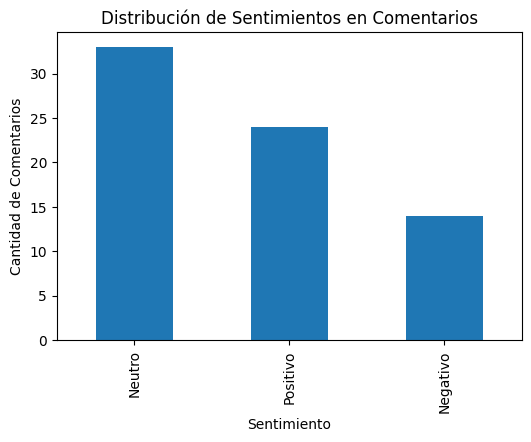

In [12]:
# 8. Visualización: gráfico de barras
df["Sentimiento"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Distribución de Sentimientos en Comentarios")
plt.ylabel("Cantidad de Comentarios")
plt.show()

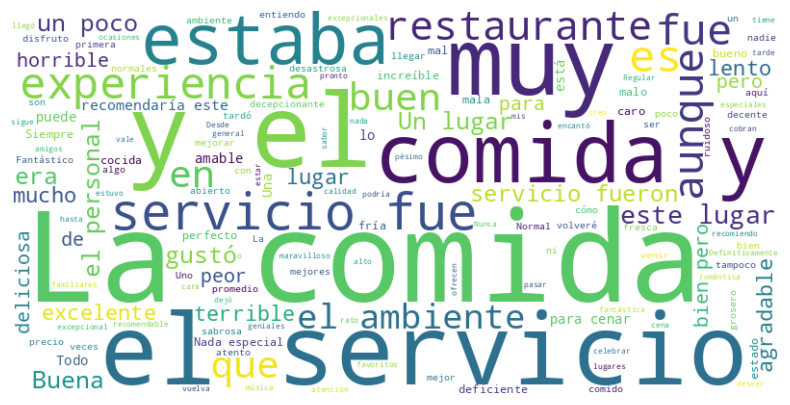

In [13]:
# 9. Visualización: nube de palabras
texto_total = " ".join(df["Comentario"].tolist())
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(texto_total)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()